# 🛒 Customer Clustering — Midterm UTS
**Mata Kuliah:** Machine Learning  
**Tugas:** End-to-End Clustering Pipeline  
**Dataset:** `clusteringmidterm.csv` — 8.950 pelanggan, 18 fitur  

---

## Tujuan
Mengelompokkan pelanggan berdasarkan perilaku penggunaan kartu kredit menggunakan metode unsupervised learning.

## Pipeline
1. Import Library
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing
5. Feature Engineering & PCA
6. Clustering (K-Means, Hierarchical, DBSCAN)
7. Evaluasi & Perbandingan Model
8. Interpretasi Cluster
9. MLFlow Tracking
10. Kesimpulan

## 1. Import Library

In [1]:
!pip install mlflow optuna scikit-learn pandas numpy matplotlib seaborn scipy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

import mlflow
import mlflow.sklearn
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print('Semua library berhasil diimport!')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
transformers 2.1.1 requires sentencepiece, which is not installed.
anaconda-cloud-auth 0.1.3 requires pydantic<2.0, but you have pydantic 2.13.4 which is incompatible.
jupyter-server 1.23.4 requires anyio<4,>=3.1.0, but you have anyio 4.13.0 which is incompatible.
numba 0.57.0 requires numpy<1.25,>=1.21, but you have numpy 1.26.4 which is incompatible.
pyopenssl 23.2.0 requires cryptography!=40.0.0,!=40.0.1,<42,>=38.0.0, but you have cryptography 46.0.7 which is incompatible.


Semua library berhasil diimport!


## 2. Load Dataset

In [2]:
# Jika di Google Colab pakai Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/PATH/clusteringmidterm.csv')

df = pd.read_csv('clusteringmidterm.csv')

print(f'Dataset loaded!')
print(f'   Jumlah baris  : {df.shape[0]}')
print(f'   Jumlah kolom  : {df.shape[1]}')
print(f'   Kolom         : {df.columns.tolist()}')
df.head()

Dataset loaded!
   Jumlah baris  : 8950
   Jumlah kolom  : 18
   Kolom         : ['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## 3. Exploratory Data Analysis (EDA)

In [3]:
print('=== Info Dataset ===')
df.info()
print()
print('=== Statistik Deskriptif ===')
df.describe().T.round(3)

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null 

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.475,2081.532,0.000,128.282,873.385,2054.140,19043.139
BALANCE_FREQUENCY,8950.0,0.877,0.237,0.000,0.889,1.000,1.000,1.000
PURCHASES,8950.0,1003.205,2136.635,0.000,39.635,361.280,1110.130,49039.570
ONEOFF_PURCHASES,8950.0,592.437,1659.888,0.000,0.000,38.000,577.405,40761.250
INSTALLMENTS_PURCHASES,8950.0,411.068,904.338,0.000,0.000,89.000,468.638,22500.000
CASH_ADVANCE,8950.0,978.871,2097.164,0.000,0.000,0.000,1113.821,47137.212
PURCHASES_FREQUENCY,8950.0,0.490,0.401,0.000,0.083,0.500,0.917,1.000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202,0.298,0.000,0.000,0.083,0.300,1.000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364,0.397,0.000,0.000,0.167,0.750,1.000
CASH_ADVANCE_FREQUENCY,8950.0,0.135,0.200,0.000,0.000,0.000,0.222,1.500


In [4]:
# Cek missing values
# Dari dataset asli: CREDIT_LIMIT (1 missing), MINIMUM_PAYMENTS (313 missing ~3.5%)
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %'    : (df.isnull().sum() / len(df) * 100).round(2)
})
print('=== Missing Values ===')
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values ===
                  Missing Count  Missing %
CREDIT_LIMIT                  1       0.01
MINIMUM_PAYMENTS            313       3.50


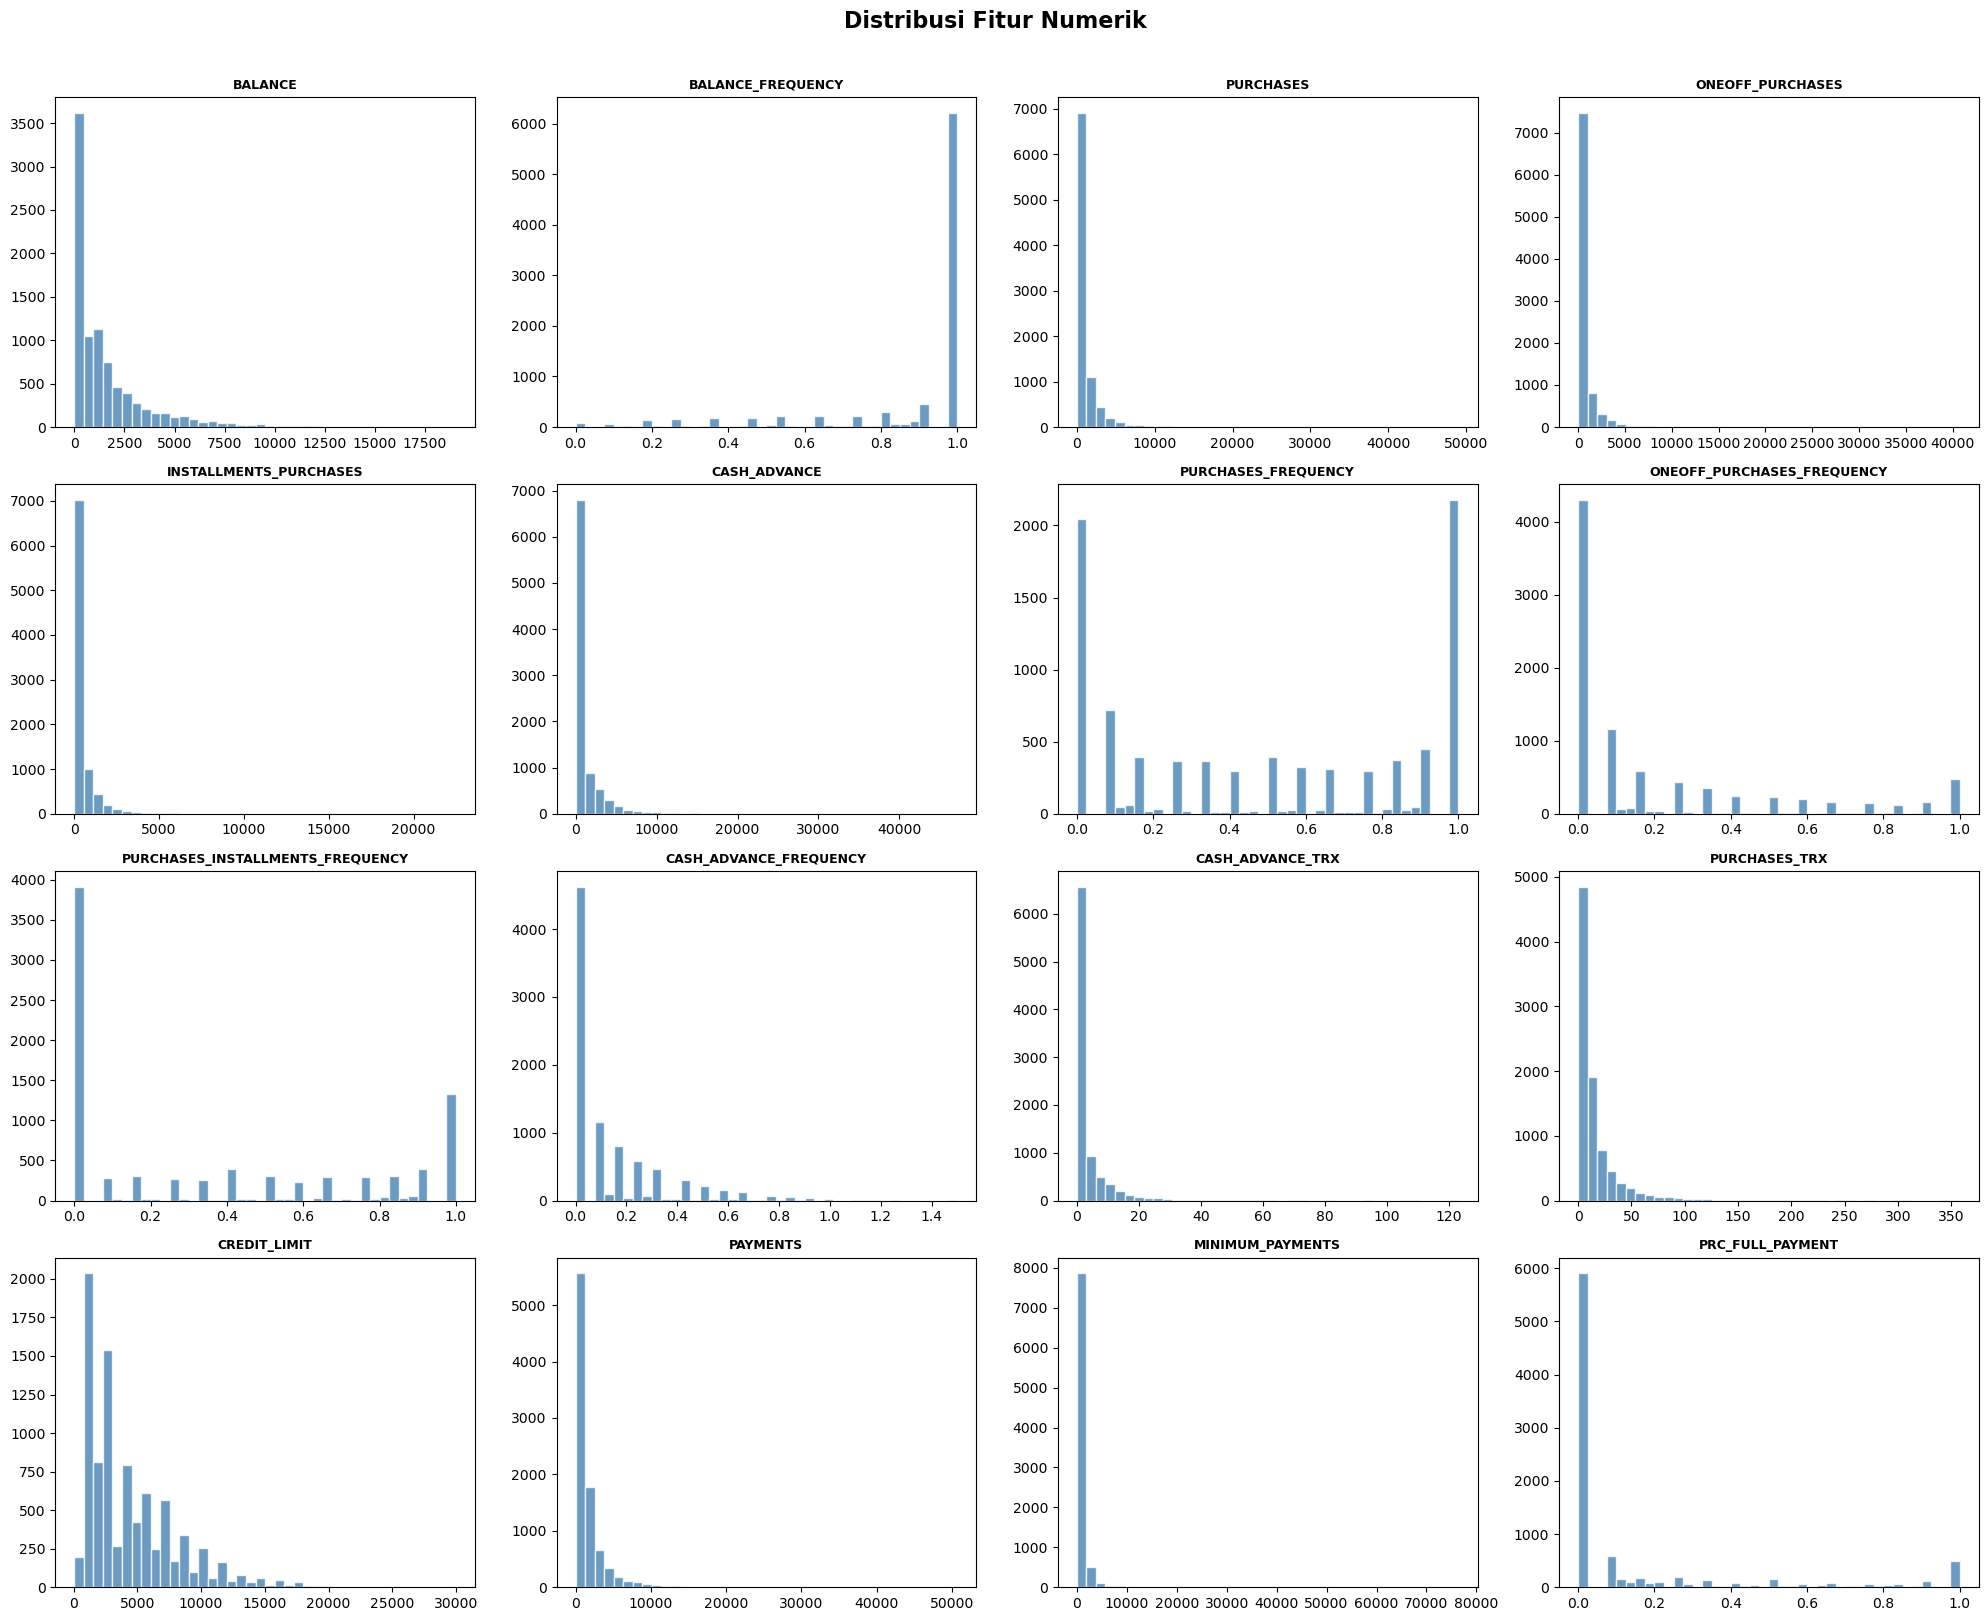

Kebanyakan fitur right-skewed — ada outlier besar di sisi kanan


In [5]:
# Distribusi fitur numerik
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(numeric_cols[:16]):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=9, fontweight='bold')

plt.suptitle('Distribusi Fitur Numerik', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distribusi_fitur.png', dpi=100, bbox_inches='tight')
plt.show()
print('Kebanyakan fitur right-skewed — ada outlier besar di sisi kanan')

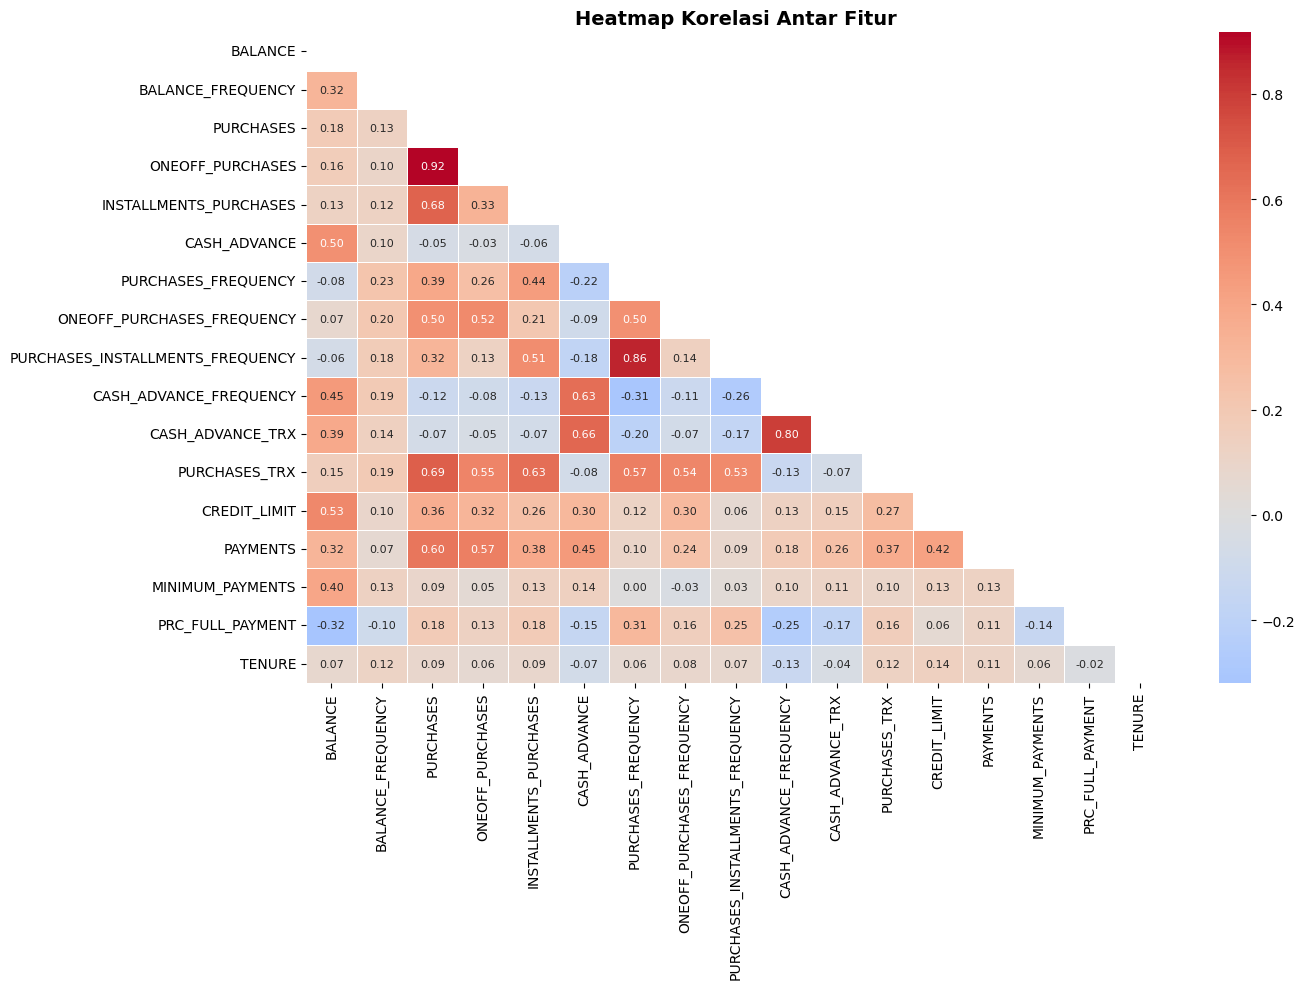

PURCHASES berkorelasi tinggi dengan ONEOFF_PURCHASES & PURCHASES_TRX


In [6]:
# Heatmap korelasi
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=100, bbox_inches='tight')
plt.show()
print('PURCHASES berkorelasi tinggi dengan ONEOFF_PURCHASES & PURCHASES_TRX')

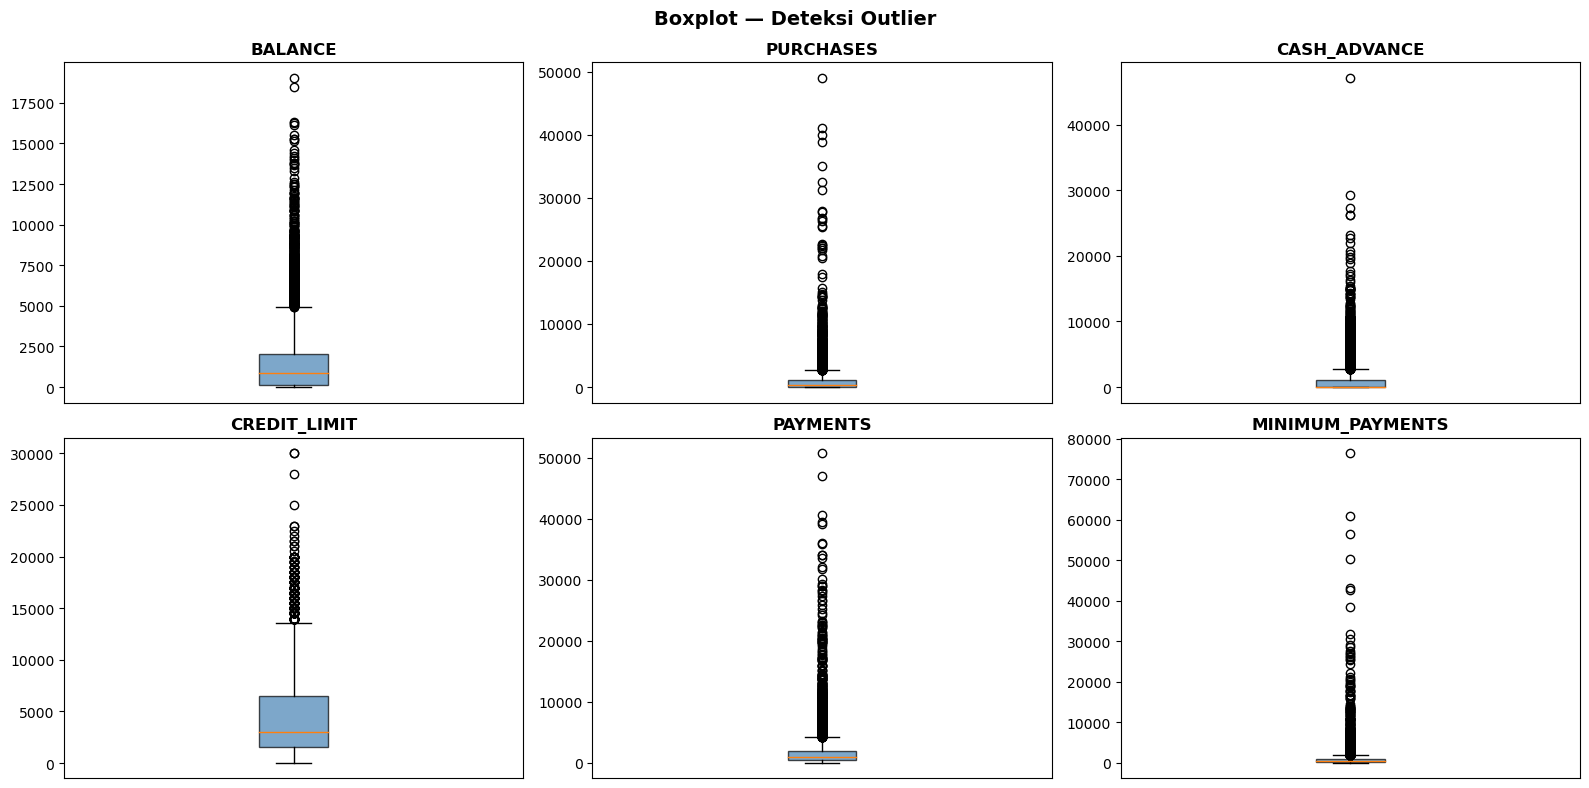

Outlier ekstrem terdeteksi pada hampir semua fitur finansial


In [7]:
# Boxplot outlier
key_cols = ['BALANCE','PURCHASES','CASH_ADVANCE','CREDIT_LIMIT','PAYMENTS','MINIMUM_PAYMENTS']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(key_cols):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xticks([])
plt.suptitle('Boxplot — Deteksi Outlier', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_outlier.png', dpi=100, bbox_inches='tight')
plt.show()
print('Outlier ekstrem terdeteksi pada hampir semua fitur finansial')

## 4. Data Preprocessing

In [8]:
# Drop kolom CUST_ID (tidak relevan untuk clustering)
df_clean = df.drop(columns=['CUST_ID']).copy()

# Handle missing values dengan median (robust terhadap outlier)
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_clean),
    columns=df_clean.columns
)
print(f'Missing sebelum : {df_clean.isnull().sum().sum()}')
print(f'Missing sesudah : {df_imputed.isnull().sum().sum()}')

Missing sebelum : 314
Missing sesudah : 0


In [9]:
# Handle outlier dengan IQR Winsorization (clip, bukan drop)
def cap_outliers_iqr(df, factor=3.0):
    df_capped = df.copy()
    n_total = 0
    for col in df.columns:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        before = df_capped[col].copy()
        df_capped[col] = df[col].clip(Q1 - factor*IQR, Q3 + factor*IQR)
        n_total += (before != df_capped[col]).sum()
    print(f'Total nilai yang di-cap: {n_total}')
    return df_capped

df_no_outlier = cap_outliers_iqr(df_imputed, factor=3.0)
print('Outlier handling selesai (IQR factor=3.0)')

Total nilai yang di-cap: 7335
Outlier handling selesai (IQR factor=3.0)


In [10]:
# Scaling dengan RobustScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_no_outlier)
X_scaled_df = pd.DataFrame(X_scaled, columns=df_no_outlier.columns)
print('RobustScaler selesai')
print(X_scaled_df.describe().loc[['mean','std']].round(3))

RobustScaler selesai
      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
mean    0.335             -0.839      0.446             0.675   
std     0.978              1.452      1.069             1.192   

      INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
mean                   0.540         0.725               -0.012   
std                    1.099         1.186                0.482   

      ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
mean                       0.397                             0.264   
std                        0.994                             0.530   

      CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX  PURCHASES_TRX  CREDIT_LIMIT  \
mean                   0.605             0.695          0.378         0.304   
std                    0.888             1.107          1.048         0.738   

      PAYMENTS  MINIMUM_PAYMENTS  PRC_FULL_PAYMENT  TENURE  
mean     0.420             0.505             0.823     0.0  
std      1

## 5. 🔧 Feature Engineering & PCA

In [11]:
df_feat = df_no_outlier.copy()

# 4 fitur baru berdasarkan domain knowledge kartu kredit
df_feat['PAYMENT_TO_BALANCE_RATIO'] = df_feat['PAYMENTS'] / (df_feat['BALANCE'] + 1)
df_feat['CASH_ADVANCE_RATIO']       = df_feat['CASH_ADVANCE'] / (df_feat['PURCHASES'] + df_feat['CASH_ADVANCE'] + 1)
df_feat['AVG_PURCHASE_VALUE']       = df_feat['PURCHASES'] / (df_feat['PURCHASES_TRX'] + 1)
df_feat['CREDIT_UTILIZATION']       = df_feat['BALANCE'] / (df_feat['CREDIT_LIMIT'] + 1)

print(f'Fitur setelah engineering: {df_feat.shape[1]}')

X_final = scaler.fit_transform(df_feat)
print(f'Shape X_final: {X_final.shape}')

Fitur setelah engineering: 21
Shape X_final: (8950, 21)


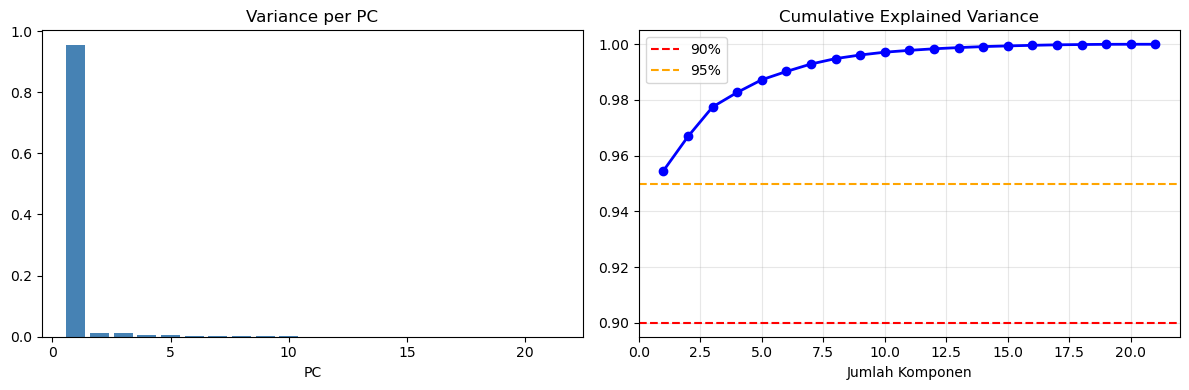

Komponen PCA untuk >=90% variance: 1
Shape X_pca: (8950, 1)


In [12]:
# PCA — pilih komponen yang explain >= 90% variance
pca_full = PCA().fit(X_final)
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='steelblue')
axes[0].set_title('Variance per PC'); axes[0].set_xlabel('PC')

axes[1].plot(range(1, len(cumulative_var)+1), cumulative_var, 'bo-', lw=2)
axes[1].axhline(0.90, color='red', ls='--', label='90%')
axes[1].axhline(0.95, color='orange', ls='--', label='95%')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xlabel('Jumlah Komponen'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=100, bbox_inches='tight')
plt.show()

n_components = int(np.argmax(cumulative_var >= 0.90) + 1)
print(f'Komponen PCA untuk >=90% variance: {n_components}')

pca   = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_final)

pca_2d = PCA(n_components=2, random_state=42)
X_2d   = pca_2d.fit_transform(X_final)
print(f'Shape X_pca: {X_pca.shape}')

## 6. Clustering
### 6.1 Menentukan K Optimal

In [13]:
inertias, sil_scores = [], []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))
    print(f'k={k:2d} | Inertia: {km.inertia_:>12.2f} | Silhouette: {sil_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(k_range, inertias, 'bo-', lw=2, ms=8)
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method'); axes[0].grid(alpha=0.3)

axes[1].plot(k_range, sil_scores, 'ro-', lw=2, ms=8)
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score per k'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=100, bbox_inches='tight')
plt.show()

best_k_manual = list(k_range)[np.argmax(sil_scores)]
print(f'\nK optimal (Silhouette): k={best_k_manual}')

AttributeError: 'NoneType' object has no attribute 'split'

### 6.2 Hyperparameter Tuning — Optuna

In [ ]:
def objective_kmeans(trial):
    n_clusters = trial.suggest_int('n_clusters', 2, 10)
    init       = trial.suggest_categorical('init', ['k-means++', 'random'])
    n_init     = trial.suggest_int('n_init', 5, 20)
    km = KMeans(n_clusters=n_clusters, init=init, n_init=n_init, random_state=42)
    return silhouette_score(X_pca, km.fit_predict(X_pca))

study_kmeans = optuna.create_study(direction='maximize')
study_kmeans.optimize(objective_kmeans, n_trials=50, show_progress_bar=True)

print(f'\nBest K-Means params : {study_kmeans.best_params}')
print(f'Best silhouette       : {study_kmeans.best_value:.4f}')

### 6.3 K-Means

In [ ]:
best_params  = study_kmeans.best_params
kmeans_best  = KMeans(n_clusters=best_params['n_clusters'],
                      init=best_params['init'],
                      n_init=best_params['n_init'], random_state=42)
kmeans_labels = kmeans_best.fit_predict(X_pca)

km_silhouette = silhouette_score(X_pca, kmeans_labels)
km_db         = davies_bouldin_score(X_pca, kmeans_labels)
km_ch         = calinski_harabasz_score(X_pca, kmeans_labels)

print('=== K-Means Evaluation ===')
print(f'N Clusters        : {best_params["n_clusters"]}')
print(f'Silhouette Score  : {km_silhouette:.4f}')
print(f'Davies-Bouldin    : {km_db:.4f}')
print(f'Calinski-Harabasz : {km_ch:.4f}')

plt.figure(figsize=(9, 6))
sc = plt.scatter(X_2d[:,0], X_2d[:,1], c=kmeans_labels, cmap='tab10', alpha=0.4, s=8)
plt.colorbar(sc, label='Cluster')
plt.title(f'K-Means (k={best_params["n_clusters"]}) — PCA 2D', fontsize=13, fontweight='bold')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('kmeans_cluster.png', dpi=100, bbox_inches='tight')
plt.show()

### 6.4 Hierarchical Clustering

In [ ]:
# Dendrogram (sample 400)
np.random.seed(42)
sample_idx = np.random.choice(len(X_pca), 400, replace=False)
linked = linkage(X_pca[sample_idx], method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=8, show_contracted=True)
plt.title('Dendrogram — Ward (sample 400)', fontsize=13, fontweight='bold')
plt.xlabel('Sample'); plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
n_clust      = best_params['n_clusters']
hierarchical = AgglomerativeClustering(n_clusters=n_clust, linkage='ward')
hier_labels  = hierarchical.fit_predict(X_pca)

hier_silhouette = silhouette_score(X_pca, hier_labels)
hier_db         = davies_bouldin_score(X_pca, hier_labels)
hier_ch         = calinski_harabasz_score(X_pca, hier_labels)

print('=== Hierarchical Evaluation ===')
print(f'Silhouette Score  : {hier_silhouette:.4f}')
print(f'Davies-Bouldin    : {hier_db:.4f}')
print(f'Calinski-Harabasz : {hier_ch:.4f}')

plt.figure(figsize=(9, 6))
sc = plt.scatter(X_2d[:,0], X_2d[:,1], c=hier_labels, cmap='tab10', alpha=0.4, s=8)
plt.colorbar(sc, label='Cluster')
plt.title(f'Hierarchical (Ward, k={n_clust}) — PCA 2D', fontsize=13, fontweight='bold')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('hierarchical_cluster.png', dpi=100, bbox_inches='tight')
plt.show()

### 6.5 DBSCAN

In [ ]:
def objective_dbscan(trial):
    eps         = trial.suggest_float('eps', 0.1, 3.0)
    min_samples = trial.suggest_int('min_samples', 3, 25)
    labels      = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_pca)
    n_cl        = len(set(labels)) - (1 if -1 in labels else 0)
    noise_r     = list(labels).count(-1) / len(labels)
    if n_cl < 2 or noise_r > 0.30:
        return -1.0
    return silhouette_score(X_pca, labels)

study_dbscan = optuna.create_study(direction='maximize')
study_dbscan.optimize(objective_dbscan, n_trials=50, show_progress_bar=True)

print(f'\nBest DBSCAN params : {study_dbscan.best_params}')
print(f'Best silhouette      : {study_dbscan.best_value:.4f}')

In [ ]:
dbscan_best   = DBSCAN(**study_dbscan.best_params)
dbscan_labels = dbscan_best.fit_predict(X_pca)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db    = list(dbscan_labels).count(-1)

print(f'Cluster ditemukan : {n_clusters_db}')
print(f'Noise points      : {n_noise_db} ({n_noise_db/len(dbscan_labels)*100:.1f}%)')

if n_clusters_db >= 2:
    db_silhouette = silhouette_score(X_pca, dbscan_labels)
    db_db         = davies_bouldin_score(X_pca, dbscan_labels)
    db_ch         = calinski_harabasz_score(X_pca, dbscan_labels)
    print(f'Silhouette Score  : {db_silhouette:.4f}')
    print(f'Davies-Bouldin    : {db_db:.4f}')
    print(f'Calinski-Harabasz : {db_ch:.4f}')
else:
    db_silhouette = db_db = db_ch = None
    print('Kurang dari 2 cluster, metrik tidak dihitung')

plt.figure(figsize=(9, 6))
sc = plt.scatter(X_2d[:,0], X_2d[:,1], c=dbscan_labels, cmap='tab10', alpha=0.4, s=8)
plt.colorbar(sc, label='Cluster (-1=noise)')
plt.title('DBSCAN — PCA 2D', fontsize=13, fontweight='bold')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout()
plt.savefig('dbscan_cluster.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Perbandingan Model

In [ ]:
results = pd.DataFrame({
    'Model'             : ['K-Means', 'Hierarchical (Ward)', 'DBSCAN'],
    'N Clusters'        : [best_params['n_clusters'], n_clust, n_clusters_db],
    'Silhouette Score'  : [round(km_silhouette,4), round(hier_silhouette,4),
                           round(db_silhouette,4) if db_silhouette else 'N/A'],
    'Davies-Bouldin'    : [round(km_db,4), round(hier_db,4),
                           round(db_db,4) if db_db else 'N/A'],
    'Calinski-Harabasz' : [round(km_ch,2), round(hier_ch,2),
                           round(db_ch,2) if db_ch else 'N/A']
})

print('=== Perbandingan Model Clustering ===')
print(results.to_string(index=False))
print()
print('Silhouette  : ↑ lebih baik (range -1 s/d 1)')
print('Davies-Bouldin : ↓ lebih baik (min=0)')
print('Calinski-Harabasz : ↑ lebih baik')

## 8. Interpretasi Cluster

In [ ]:
# Gabungkan label ke dataframe original
df_result = df_no_outlier.copy()
df_result['Cluster'] = kmeans_labels

cluster_profile = df_result.groupby('Cluster').mean().round(2)
cluster_size    = df_result['Cluster'].value_counts().sort_index()

print('=== Ukuran Cluster ===')
for c, cnt in cluster_size.items():
    bar =  * int(cnt / len(df_result) * 50)
    print(f'  Cluster {c}: {cnt:5d} ({cnt/len(df_result)*100:.1f}%)  {bar}')

print()
print('=== Profil Rata-Rata ===')
cluster_profile

In [ ]:
# Radar chart
key_features = ['BALANCE','PURCHASES','CASH_ADVANCE','CREDIT_LIMIT',
                'PAYMENTS','PRC_FULL_PAYMENT','PURCHASES_FREQUENCY']

profile_norm = cluster_profile[key_features].copy()
for col in profile_norm.columns:
    rng = profile_norm[col].max() - profile_norm[col].min()
    profile_norm[col] = (profile_norm[col] - profile_norm[col].min()) / (rng + 1e-8)

n_cf   = len(cluster_profile)
n_feat = len(key_features)
angles = np.linspace(0, 2*np.pi, n_feat, endpoint=False).tolist() + [0]
colors = plt.cm.tab10(np.linspace(0, 1, n_cf))

cols_r = min(n_cf, 4)
rows_r = (n_cf + cols_r - 1) // cols_r
fig, axes = plt.subplots(rows_r, cols_r,
                          figsize=(5*cols_r, 5*rows_r),
                          subplot_kw=dict(polar=True))
axes = np.array(axes).flatten()

for i, (idx, row) in enumerate(profile_norm.iterrows()):
    vals = row.tolist() + [row.tolist()[0]]
    axes[i].plot(angles, vals, color=colors[i], linewidth=2)
    axes[i].fill(angles, vals, color=colors[i], alpha=0.25)
    axes[i].set_xticks(angles[:-1])
    axes[i].set_xticklabels(key_features, size=8)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'Cluster {idx} (n={cluster_size[idx]})',
                      size=11, fontweight='bold', pad=15)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Profil Cluster — Radar Chart', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# Boxplot per cluster
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(key_features):
    df_result.boxplot(column=col, by='Cluster', ax=axes[i])
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Cluster')
for j in range(len(key_features), len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Distribusi Fitur per Cluster', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_cluster.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
# Interpretasi naratif
print('=' * 65)
print('INTERPRETASI CLUSTER')
print('=' * 65)

for cluster_id in sorted(df_result['Cluster'].unique()):
    sub = df_result[df_result['Cluster'] == cluster_id]
    n   = len(sub)
    avg_balance   = sub['BALANCE'].mean()
    avg_purchases = sub['PURCHASES'].mean()
    avg_cash      = sub['CASH_ADVANCE'].mean()
    avg_prc_full  = sub['PRC_FULL_PAYMENT'].mean()
    avg_purch_f   = sub['PURCHASES_FREQUENCY'].mean()
    avg_cl        = sub['CREDIT_LIMIT'].mean()
    avg_pay       = sub['PAYMENTS'].mean()

    print(f'\n Cluster {cluster_id}  ({n} pelanggan, {n/len(df_result)*100:.1f}%)')
    print(f'   Avg Balance         : {avg_balance:>10,.1f}')
    print(f'   Avg Purchases       : {avg_purchases:>10,.1f}')
    print(f'   Avg Cash Advance    : {avg_cash:>10,.1f}')
    print(f'   Avg Payments        : {avg_pay:>10,.1f}')
    print(f'   Avg Credit Limit    : {avg_cl:>10,.1f}')
    print(f'   Full Payment Ratio  : {avg_prc_full:>10.3f}')
    print(f'   Purchase Frequency  : {avg_purch_f:>10.3f}')

    if avg_prc_full > 0.4 and avg_purchases > 1500:
        label = 'Premium Spender — Belanja banyak & rutin bayar penuh'
    elif avg_cash > avg_purchases * 0.8 and avg_prc_full < 0.15:
        label = ' Cash Advance Heavy — Tarik tunai dominan, risiko tinggi'
    elif avg_purchases > 800 and avg_purch_f > 0.6:
        label = ' Active Shopper — Belanja rutin, frekuensi tinggi'
    elif avg_balance > 2500 and avg_prc_full < 0.05:
        label = 'High Revolving — Saldo tinggi, jarang bayar penuh'
    elif avg_purchases < 300 and avg_cash < 300:
        label = 'Low Activity — Kartu jarang dipakai'
    else:
        label = 'Moderate User — Penggunaan kartu sedang'

    print(f'   → Segmen : {label}')

print('\n' + '=' * 65)

## 9. MLFlow Tracking

In [ ]:
mlflow.set_experiment('customer_clustering_midterm')

# K-Means
with mlflow.start_run(run_name='KMeans_optuna'):
    mlflow.log_params({'model': 'KMeans', **best_params,
                       'scaler': 'RobustScaler', 'pca_components': n_components,
                       'outlier_handling': 'IQR_cap_factor3'})
    mlflow.log_metrics({'silhouette_score': km_silhouette,
                        'davies_bouldin_score': km_db,
                        'calinski_harabasz_score': km_ch})
    for f in ['kmeans_cluster.png','radar_chart.png','elbow_silhouette.png']:
        mlflow.log_artifact(f)
    mlflow.sklearn.log_model(kmeans_best, 'kmeans_model')
print('K-Means logged')

# Hierarchical
with mlflow.start_run(run_name='Hierarchical_Ward'):
    mlflow.log_params({'model': 'AgglomerativeClustering', 'n_clusters': n_clust,
                       'linkage': 'ward', 'scaler': 'RobustScaler',
                       'pca_components': n_components})
    mlflow.log_metrics({'silhouette_score': hier_silhouette,
                        'davies_bouldin_score': hier_db,
                        'calinski_harabasz_score': hier_ch})
    for f in ['hierarchical_cluster.png','dendrogram.png']:
        mlflow.log_artifact(f)
    mlflow.sklearn.log_model(hierarchical, 'hierarchical_model')
print('Hierarchical logged')

# DBSCAN
with mlflow.start_run(run_name='DBSCAN_optuna'):
    mlflow.log_params({'model': 'DBSCAN', **study_dbscan.best_params,
                       'n_clusters_found': n_clusters_db, 'noise_points': n_noise_db})
    if db_silhouette:
        mlflow.log_metrics({'silhouette_score': db_silhouette,
                            'davies_bouldin_score': db_db,
                            'calinski_harabasz_score': db_ch})
    mlflow.log_artifact('dbscan_cluster.png')
    mlflow.sklearn.log_model(dbscan_best, 'dbscan_model')
print('DBSCAN logged')

print()
print('Jalankan: mlflow ui  →  http://localhost:5000')

## 10. Kesimpulan

### Ringkasan Pipeline

| Tahap | Detail |
|---|---|
| Dataset | `clusteringmidterm.csv` — 8.950 baris, 18 kolom |
| Missing Values | CREDIT_LIMIT (1), MINIMUM_PAYMENTS (313) → diisi median |
| Outlier Handling | IQR Winsorization (factor=3.0) |
| Scaling | RobustScaler |
| Feature Engineering | +4 fitur baru (rasio bisnis) |
| Reduksi Dimensi | PCA (≥90% variance explained) |
| Tuning | Optuna (50 trials per model) |
| Tracking | MLFlow |

### Segmentasi Pelanggan

| Segmen | Rekomendasi Bisnis |
|---|---|
| Premium Spender | Upselling, reward eksklusif |
| Active Shopper | Program cashback / loyalty points |
| Cash Advance Heavy | Edukasi finansial, monitor risiko kredit |
| High Revolving Balance | Tawarkan produk restrukturisasi cicilan |
| Low Activity | Kampanye reaktivasi dengan insentif |
| Moderate User | Produk kartu standar, dorong peningkatan usage |